# Plotting Reconstructed Features

Reconstructing features to a time in the past involves moving geological or geographic data (like coastlines, plate boundaries, or fossil sites) back through time using a plate motion model. Once reconstructed, these features are plotted to visualize their past positions.

### Setup

Let's begin by importing the required packages:

In [2]:
# Ensure you have the required packages installed:
# Run `pip install gplately matplotlib` if not already installed.

import gplately
import matplotlib.pyplot as plt
from plate_model_manager import PlateModelManager

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

`NOTE:` You can also load a plate model through local files on your system!

In [3]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
try:
    muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../../data/plate-model-repo")
except Exception as e:
    print(f"Error loading model: {e}")

# Fetch components of the loaded model
rotation_model_2019 = muller2019_model.get_rotation_model()
topology_features_2019 = muller2019_model.get_topologies()
static_polygons_2019 = muller2019_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model_2019, topology_features_2019, static_polygons_2019)

### Reconstruct Geological Features

The plate motion model we created can be used to generate plate reconstructions through geological time. Let's reconstruct subduction zones and mid-ocean ridges to 150 Ma. Here, 

- Subduction points are shown as blue dots

- Ridge points are shown as red dots

    Either the subduction polarity is not properly set or there are too many subducting plates sharing the sub-segment.
    Ignoring current sub-segment.


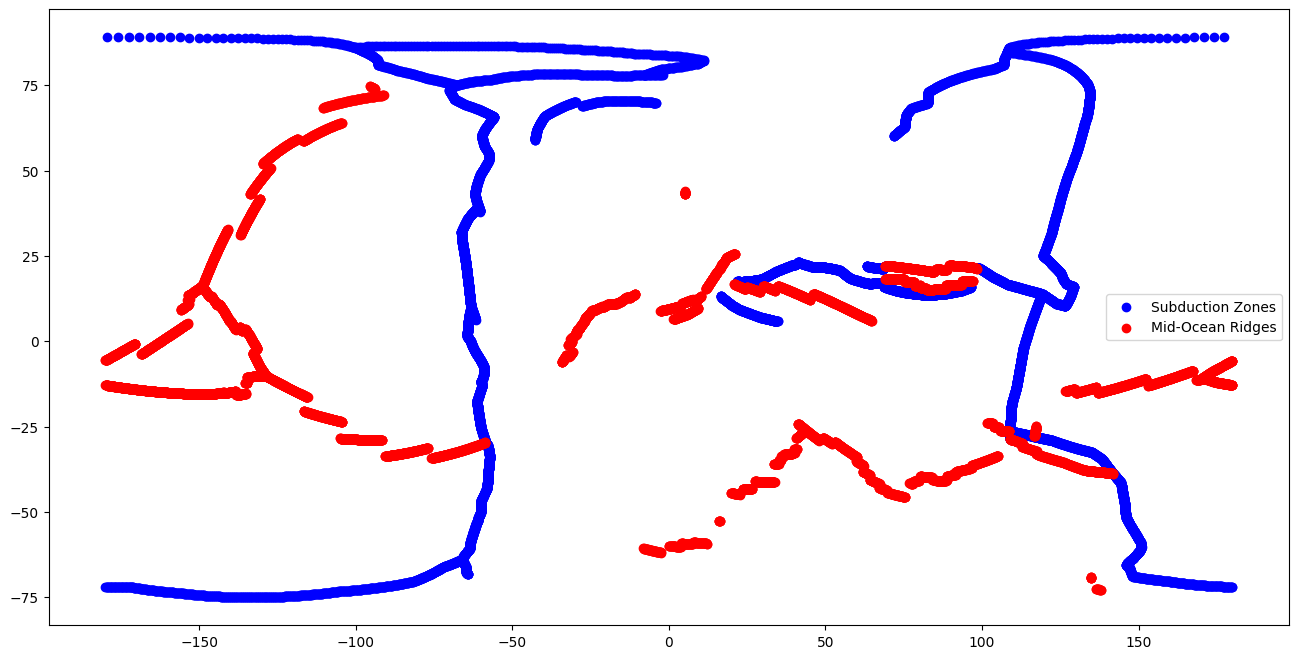

In [4]:
time = 150  # Ma

# --- Plot ridges and trenches at 150 Ma

subduction_data = model.tessellate_subduction_zones(time)   # Tessellate subduction zones at 150 Ma
ridge_data = model.tessellate_mid_ocean_ridges(time)    # Tessellate mid-ocean ridges at 150 Ma

# Create a new figure (16 x 8 inches in size)
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(111)

# Plot subduction zone points as blue dots
ax1.scatter(subduction_data[:, 0],  # longitudes
            subduction_data[:, 1],  # latitudes
            color='blue',
            label='Subduction Zones')

# Plot mid-ocean ridge points as red dots
ax1.scatter(ridge_data[:, 0],
            ridge_data[:, 1],
            color='red',
            label='Mid-Ocean Ridges')

ax1.legend()
plt.show()